<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); 
            padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
  <h1 style="color:#e94560; font-size:2.6em; margin:0 0 8px 0; font-family:'Segoe UI',sans-serif; letter-spacing:2px;">
    ⚙️ StockSense
  </h1>
  <h2 style="color:#a8dadc; font-size:1.3em; margin:0 0 18px 0; font-weight:400; font-family:'Segoe UI',sans-serif;">
    Risk-Aware ML Procurement Orchestrator
  </h2>
  <hr style="border:none; border-top:1px solid #e9456044; margin:16px 0;">
  <table style="color:#ccc; font-family:'Segoe UI',sans-serif; font-size:0.92em; border-collapse:collapse;">
    <tr><td style="padding:3px 24px 3px 0; color:#a8dadc; font-weight:600;">Author</td><td>ChinnappaSwami</td></tr>
    <tr><td style="padding:3px 24px 3px 0; color:#a8dadc; font-weight:600;">Version</td><td>StockSense</td></tr>
    <tr><td style="padding:3px 24px 3px 0; color:#a8dadc; font-weight:600;">Theme</td><td>Supply Chain Resilience &amp; Logistics Intelligence</td></tr>
    <tr><td style="padding:3px 24px 3px 0; color:#a8dadc; font-weight:600;">Objective</td><td>Predict vendor delay &amp; fulfillment risk → prescribe risk-adjusted purchase orders</td></tr>
  </table>
</div>

---

### 📋 Notebook Structure

| # | Section | Description |
|---|---------|-------------|
| 1 | **Environment Setup** | Library imports, plot config, reproducibility seeds |
| 2 | **Data Ingestion** | Load BOM, vendor history & external signals from CSV |
| 3 | **Exploratory Data Analysis** | Delay distributions, seasonal patterns, vendor heatmaps |
| 4 | **Feature Engineering** | Compute risk scores, encode categoricals, build ML-ready features |
| 5 | **Model Training** | Delay Regressor · Fulfillment Regressor · Risk Classifier |
| 6 | **Model Evaluation** | MAE, RMSE, R², AUC-ROC, confusion matrix, cross-validation |
| 7 | **Procurement Orchestration** | BOM explosion → risk-adjusted POs → split-sourcing recommendations |
| 8 | **Results Summary** | Final metrics dashboard & output export |

> **Data files required** (place in a `data/` folder next to this notebook):  
> `data/bom_master.csv` · `data/vendor_history.csv` · `data/external_signals.csv`


---
## 1 · Environment Setup


In [26]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               RandomForestClassifier)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              accuracy_score, f1_score)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot aesthetics ──────────────────────────────────────────────────────────
PALETTE   = ["#e94560", "#0f3460", "#a8dadc", "#457b9d", "#f1a208", "#2ec4b6"]
sns.set_style("whitegrid")
sns.set_palette(PALETTE)
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

print("✅  Environment ready — all libraries imported successfully.")


✅  Environment ready — all libraries imported successfully.


---
## 2 · Data Ingestion

Three source tables are loaded from the `data/` directory:

| Table | File | Description |
|-------|------|-------------|
| **BOM Master** | `bom_master.csv` | Product → Component mapping with lead times & criticality |
| **Vendor History** | `vendor_history.csv` | 5,000 historical order records with delay & fulfillment outcomes |
| **External Signals** | `external_signals.csv` | Monthly risk indices per vendor (port congestion, weather, sentiment, FX) |


In [55]:
DATA_DIR = "data"

# ── Load datasets ────────────────────────────────────────────────────────────
bom_df    = pd.read_csv(f"{DATA_DIR}/bom_master.csv")
vendor_df = pd.read_csv(f"{DATA_DIR}/vendor_history.csv",
                        parse_dates=["promised_date", "actual_date"])
ext_df    = pd.read_csv(f"{DATA_DIR}/external_signals.csv")

# ── Derive core outcome columns ──────────────────────────────────────────────
vendor_df["delay_days"]        = (vendor_df["actual_date"] - vendor_df["promised_date"]).dt.days
vendor_df["fulfillment_ratio"] = vendor_df["qty_received"] / vendor_df["qty_ordered"]

# ── Quick sanity check ───────────────────────────────────────────────────────
print(f"{'Table':<22} {'Rows':>6}  {'Cols':>5}")
print("─" * 38)
for name, df in [("BOM Master", bom_df), ("Vendor History", vendor_df), ("External Signals", ext_df)]:
    print(f"{name:<22} {df.shape[0]:>6,}  {df.shape[1]:>5}")
print()
print("Vendor History — column types:")
print(vendor_df.dtypes.to_string())


Table                    Rows   Cols
──────────────────────────────────────
BOM Master                 29      5
Vendor History          5,000     20
External Signals           72      6

Vendor History — column types:
vendor_id                           str
component_id                        str
promised_date            datetime64[us]
actual_date              datetime64[us]
qty_ordered                       int64
qty_received                      int64
order_month                       int64
seasonal_flag                     int64
component_lead_days               int64
criticality_score               float64
on_time_rate_12m                float64
hist_avg_delay_days             float64
hist_fulfillment_rate           float64
port_congestion_idx             float64
weather_risk_score              float64
news_sentiment                  float64
currency_volatility             float64
high_risk                         int64
delay_days                        int64
fulfillment_ratio    

In [56]:
# ── Preview each table ───────────────────────────────────────────────────────
print("═" * 50)
print("  BOM Master (first 5 rows)")
print("═" * 50)
display(bom_df.head())

print("\n" + "═" * 50)
print("  Vendor History (first 5 rows)")
print("═" * 50)
display(vendor_df.head())

print("\n" + "═" * 50)
print("  External Signals (first 5 rows)")
print("═" * 50)
display(ext_df.head())


══════════════════════════════════════════════════
  BOM Master (first 5 rows)
══════════════════════════════════════════════════


,product_id,component_id,qty_per_unit,standard_lead_days,criticality_score
0,DRILL_01,CABLE_R,10,8,0.70
1,DRILL_01,CASING_B,20,7,0.60
2,DRILL_01,SWITCH_S,1,6,0.65
3,DRILL_01,BLADE_X,2,12,0.85
4,DRILL_02,BEARING_01,2,11,0.80



══════════════════════════════════════════════════
  Vendor History (first 5 rows)
══════════════════════════════════════════════════


,vendor_id,component_id,promised_date,actual_date,qty_ordered,qty_received,order_month,seasonal_flag,component_lead_days,criticality_score,on_time_rate_12m,hist_avg_delay_days,hist_fulfillment_rate,port_congestion_idx,weather_risk_score,news_sentiment,currency_volatility,high_risk,delay_days,fulfillment_ratio
0,VND_ALPHA,BATTERY_A,2022-07-18,2022-07-19,2206,1996,7,0,10,0.90,0.8117,0.803,0.9423,2.66,1.71,-0.565,1.150,0,1,0.904805
1,VND_BETA,SCREW_M4,2021-07-29,2021-08-02,5743,5534,7,0,5,0.40,0.6081,2.945,0.8974,8.11,6.76,-1.000,3.129,0,4,0.963608
2,VND_EPSILON,BATTERY_A,2023-05-15,2023-05-15,460,405,5,0,10,0.90,0.7599,1.744,0.9294,5.37,6.65,-0.289,2.054,0,0,0.880435
3,VND_ALPHA,MOTOR_X,2022-03-24,2022-03-25,2105,1896,3,0,14,0.95,0.8665,1.621,0.9468,2.73,2.14,-0.359,0.814,0,1,0.900713
4,VND_EPSILON,MOTOR_X,2022-02-12,2022-02-16,6065,5651,2,0,14,0.95,0.7573,1.376,0.9397,3.97,2.95,-0.443,1.143,1,4,0.931739



══════════════════════════════════════════════════
  External Signals (first 5 rows)
══════════════════════════════════════════════════


,vendor_id,month,port_congestion_idx,weather_risk_score,news_sentiment,currency_volatility
0,VND_ALPHA,1,3.70,2.96,-0.026,1.609
1,VND_ALPHA,2,2.97,1.37,0.254,1.307
2,VND_ALPHA,3,2.73,2.14,-0.359,0.814
3,VND_ALPHA,4,3.44,0.00,-0.737,0.775
4,VND_ALPHA,5,2.19,1.91,-0.492,0.435


---
## 3 · Exploratory Data Analysis

### 3.1 · Descriptive Statistics


In [28]:
print("Vendor History — Descriptive Statistics")
display(vendor_df[["delay_days","fulfillment_ratio","qty_ordered","qty_received"]].describe().round(3))


Vendor History — Descriptive Statistics


,delay_days,fulfillment_ratio,qty_ordered,qty_received
count,5000.000,5000.000,5000.000,5000.000
mean,1.568,0.904,4085.511,3694.700
std,2.440,0.097,2244.607,2076.042
min,-2.000,0.505,200.000,142.000
25%,0.000,0.846,2156.500,1938.500
50%,1.000,0.927,4058.000,3642.500
75%,3.000,0.999,6047.000,5422.000
max,15.000,1.000,8000.000,7991.000


### 3.2 · Delay Distribution by Vendor

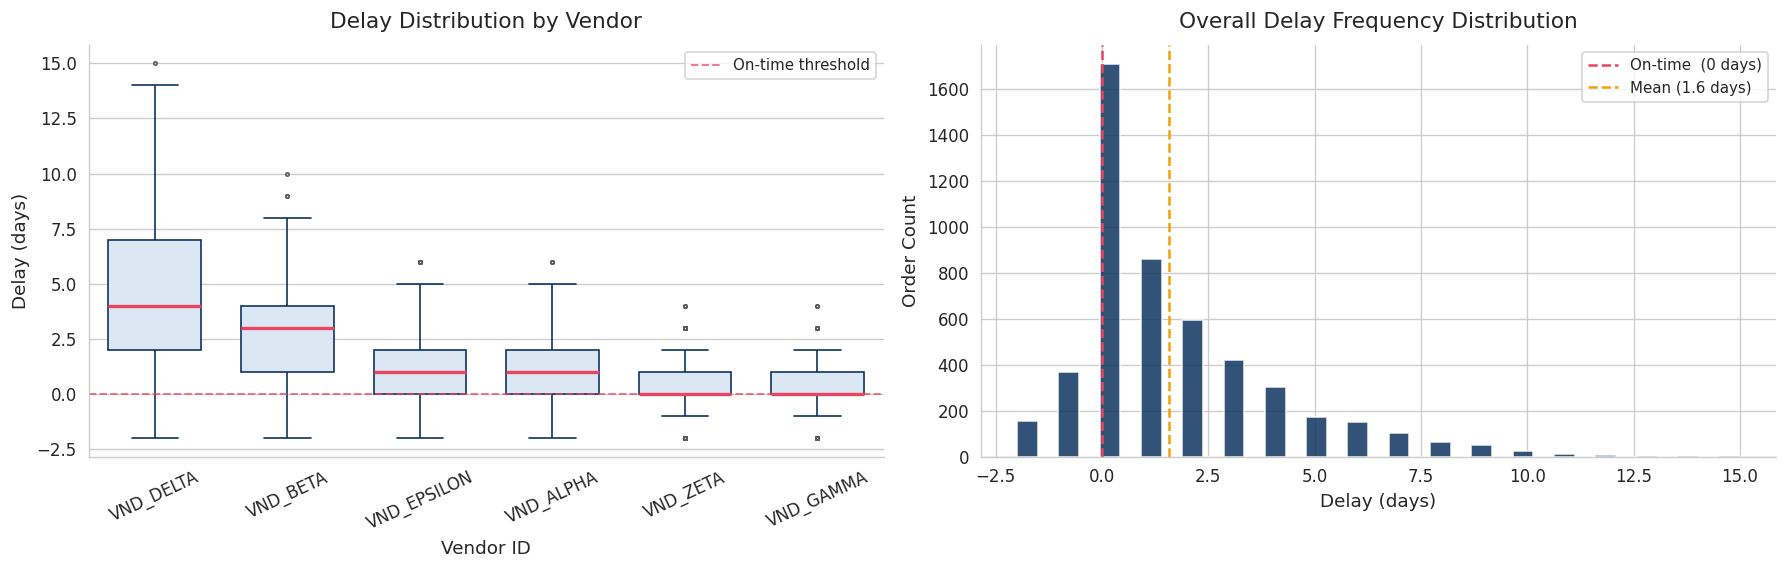

In [29]:
vendor_order = (vendor_df.groupby("vendor_id")["delay_days"]
                .mean().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Delivery Delay Analysis", fontsize=15, fontweight="bold", y=1.01)

# — Boxplot —
sns.boxplot(data=vendor_df, x="vendor_id", y="delay_days",
            order=vendor_order, ax=axes[0], width=0.7, fliersize=2,
            boxprops=dict(facecolor="#dbe7f3", edgecolor="#0f3460"),
            medianprops=dict(color="#e94560", linewidth=2),
            whiskerprops=dict(color="#0f3460"),
            capprops=dict(color="#0f3460"))
axes[0].axhline(0, color="#e94560", linestyle="--", linewidth=1.2, alpha=0.7, label="On-time threshold")
axes[0].set_title("Delay Distribution by Vendor", pad=10)
axes[0].set_xlabel("Vendor ID"); axes[0].set_ylabel("Delay (days)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(fontsize=9)

# — Histogram —
axes[1].hist(vendor_df["delay_days"], bins=35, color="#0f3460", edgecolor="white", alpha=0.85)
axes[1].axvline(0,  color="#e94560",  linestyle="--", linewidth=1.5, label="On-time  (0 days)")
axes[1].axvline(vendor_df["delay_days"].mean(), color="#f1a208",
                linestyle="--", linewidth=1.5,
                label=f"Mean ({vendor_df['delay_days'].mean():.1f} days)")
axes[1].set_title("Overall Delay Frequency Distribution", pad=10)
axes[1].set_xlabel("Delay (days)"); axes[1].set_ylabel("Order Count")
axes[1].legend(fontsize=9)

plt.suptitle("")
plt.tight_layout()
plt.show()


### 3.3 · Fulfillment Rate & Seasonal Patterns

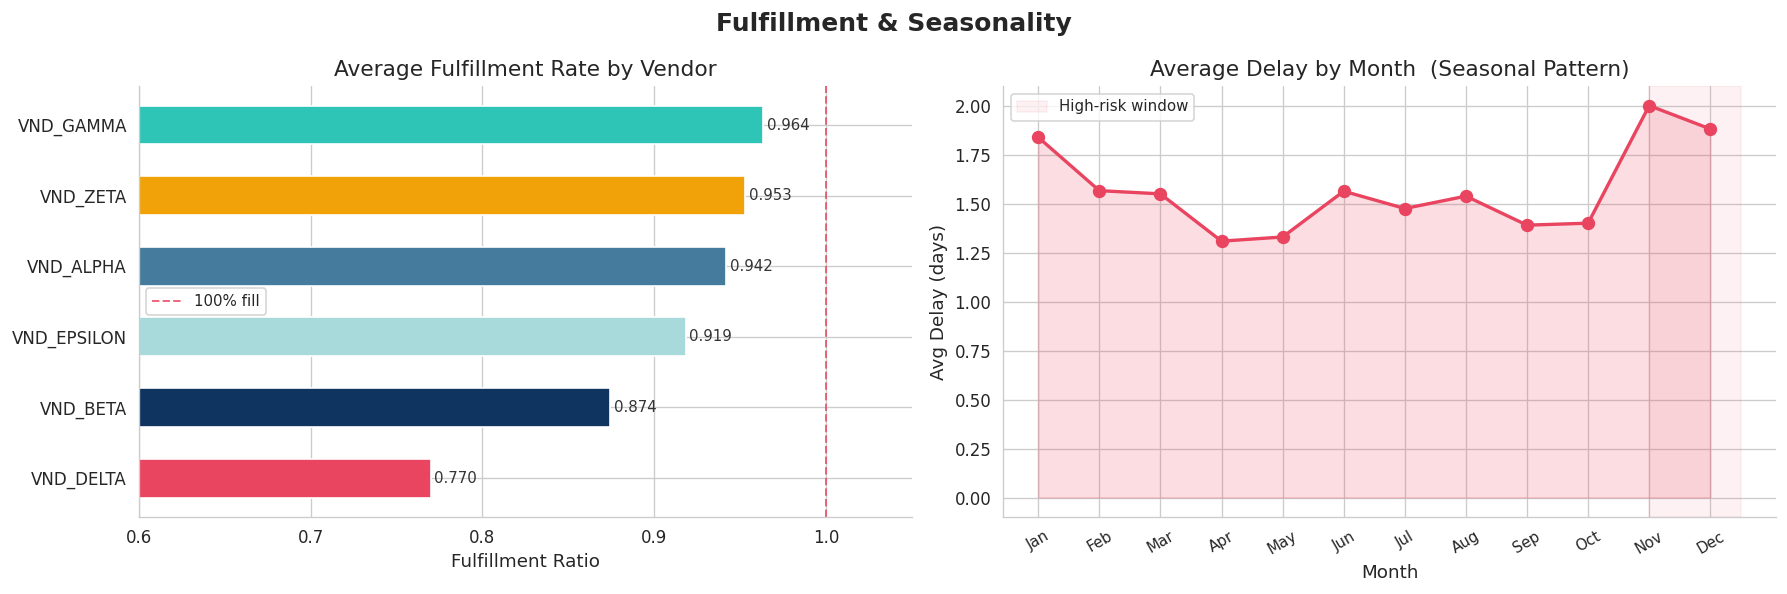

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Fulfillment & Seasonality", fontsize=15, fontweight="bold")

# — Fulfillment by vendor —
fr_data = (vendor_df.groupby("vendor_id")["fulfillment_ratio"]
           .mean().sort_values().reset_index())
bars = axes[0].barh(fr_data["vendor_id"], fr_data["fulfillment_ratio"],
                    color=PALETTE[:len(fr_data)], edgecolor="white", height=0.55)
axes[0].axvline(1.0, color="#e94560", linestyle="--", linewidth=1.2, alpha=0.8, label="100% fill")
axes[0].set_title("Average Fulfillment Rate by Vendor")
axes[0].set_xlabel("Fulfillment Ratio")
axes[0].set_xlim(0.6, 1.05)
for bar, v in zip(bars, fr_data["fulfillment_ratio"]):
    axes[0].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=9, color="#333")
axes[0].legend(fontsize=9)

# — Monthly delay trend —
monthly = vendor_df.groupby("order_month")["delay_days"].mean()
axes[1].fill_between(monthly.index, monthly.values, alpha=0.18, color="#e94560")
axes[1].plot(monthly.index, monthly.values, marker="o", color="#e94560",
             linewidth=2, markersize=7)
axes[1].set_title("Average Delay by Month  (Seasonal Pattern)")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Avg Delay (days)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30, fontsize=9)
axes[1].axvspan(11, 12.5, alpha=0.07, color="#e94560", label="High-risk window")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### 3.4 · Vendor × Component Risk Heatmap

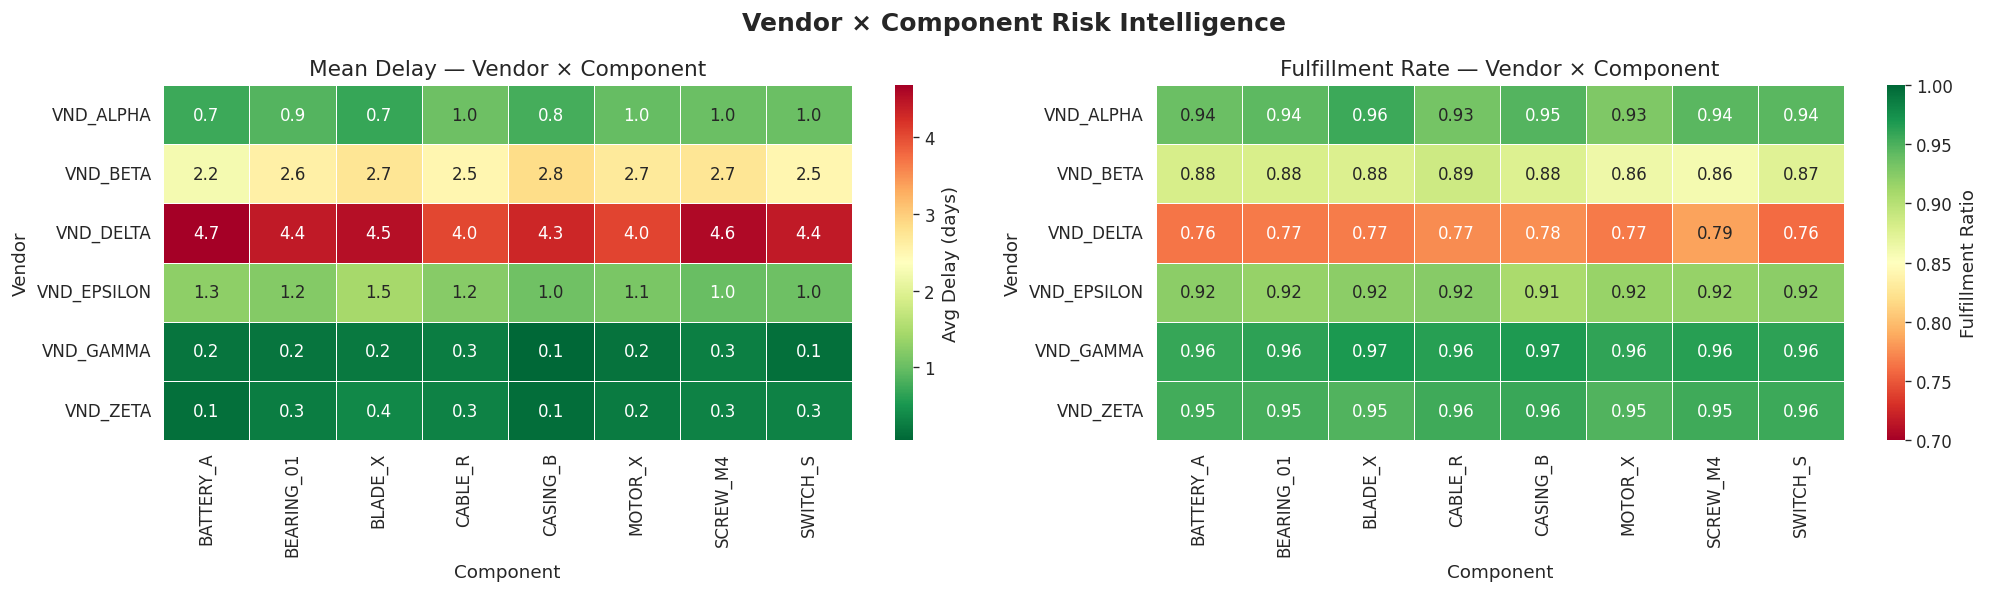

In [54]:
pivot_delay = (vendor_df.groupby(["vendor_id","component_id"])["delay_days"]
               .mean().unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("Vendor × Component Risk Intelligence", fontsize=15, fontweight="bold")

sns.heatmap(pivot_delay, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=axes[0], cbar_kws={"label":"Avg Delay (days)"})
axes[0].set_title("Mean Delay — Vendor × Component")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Vendor")

pivot_fill = (vendor_df.groupby(["vendor_id","component_id"])["fulfillment_ratio"]
              .mean().unstack(fill_value=1))
sns.heatmap(pivot_fill, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[1], vmin=0.7, vmax=1.0,
            cbar_kws={"label":"Fulfillment Ratio"})
axes[1].set_title("Fulfillment Rate — Vendor × Component")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Vendor")

plt.tight_layout()
plt.show()


### 3.5 · Correlation Analysis

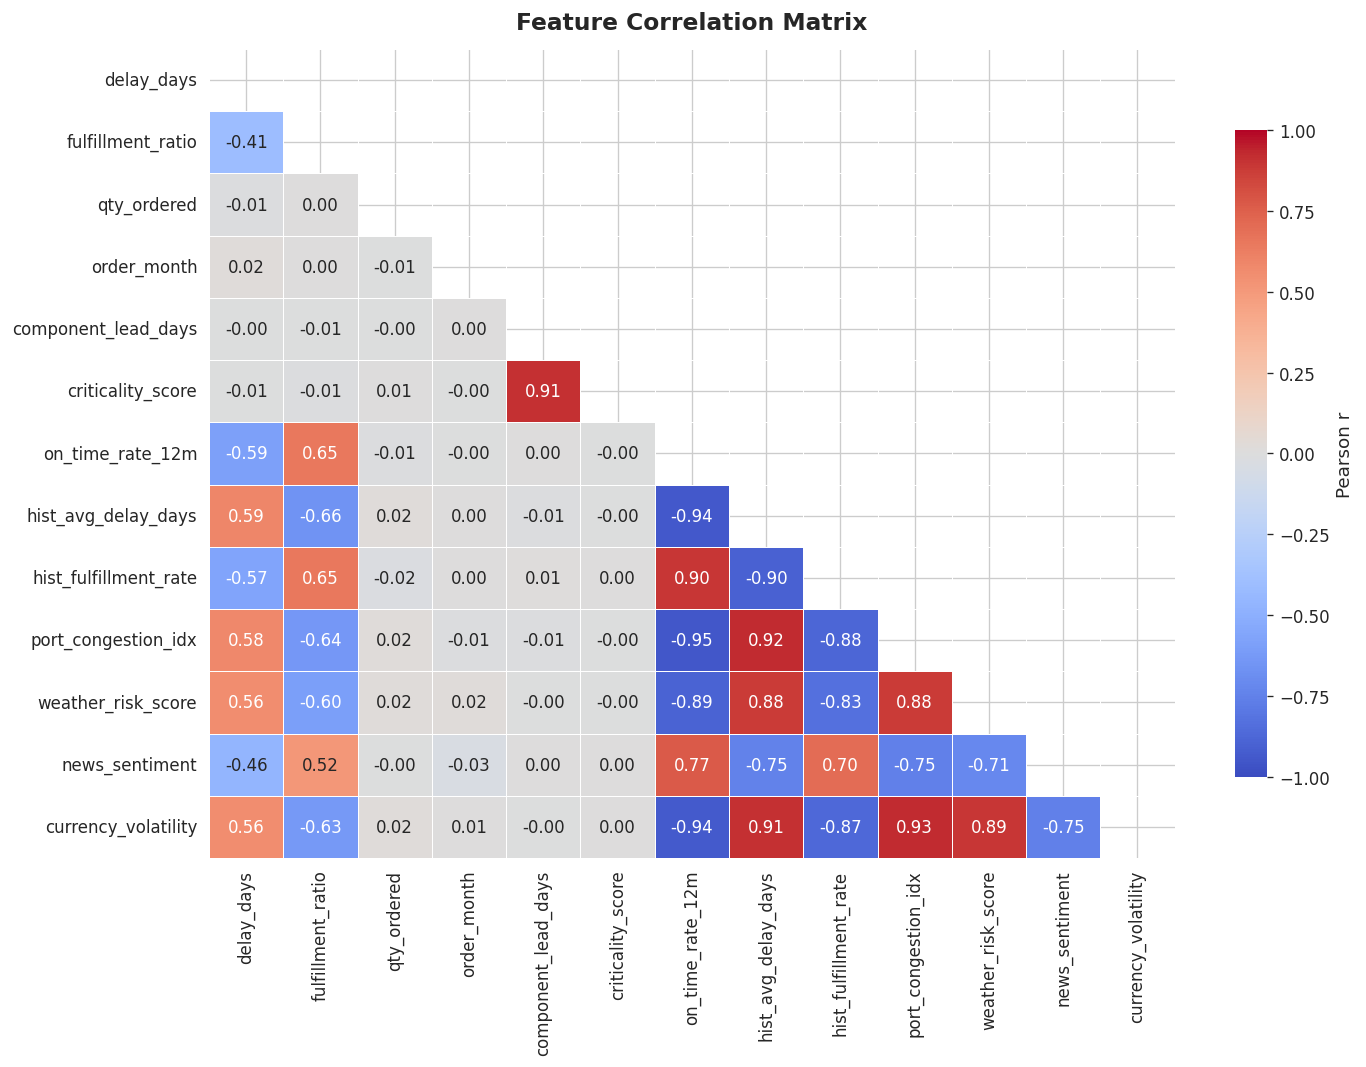

In [33]:
num_cols = ["delay_days","fulfillment_ratio","qty_ordered",
            "order_month","component_lead_days","criticality_score",
            "on_time_rate_12m","hist_avg_delay_days","hist_fulfillment_rate",
            "port_congestion_idx","weather_risk_score","news_sentiment","currency_volatility"]

corr = vendor_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### 3.6 · High-Risk Class Distribution

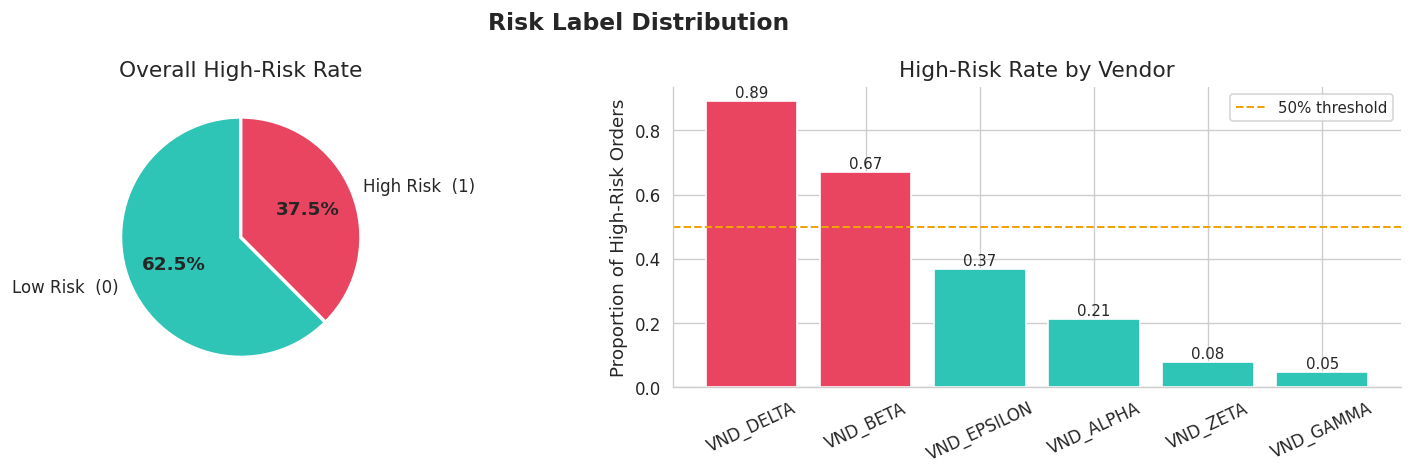

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Risk Label Distribution", fontsize=14, fontweight="bold")

# — Overall —
counts = vendor_df["high_risk"].value_counts().sort_index()
labels = ["Low Risk  (0)", "High Risk  (1)"]
colors = ["#2ec4b6", "#e94560"]
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct="%1.1f%%",
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for at in autotexts: at.set_fontsize(11); at.set_fontweight("bold")
axes[0].set_title("Overall High-Risk Rate")

# — By vendor —
risk_by_vendor = vendor_df.groupby("vendor_id")["high_risk"].mean().sort_values(ascending=False)
bars = axes[1].bar(risk_by_vendor.index, risk_by_vendor.values,
                   color=[("#e94560" if v > 0.5 else "#2ec4b6") for v in risk_by_vendor.values],
                   edgecolor="white")
axes[1].axhline(0.5, color="#f1a208", linestyle="--", linewidth=1.2, label="50% threshold")
axes[1].set_title("High-Risk Rate by Vendor")
axes[1].set_ylabel("Proportion of High-Risk Orders")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(fontsize=9)
for bar, v in zip(bars, risk_by_vendor.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


---
## 4 · Feature Engineering & Preprocessing

The ML models consume three categories of features:

| Category | Features | Source |
|----------|----------|--------|
| **Vendor Behavior** | `on_time_rate_12m`, `hist_avg_delay_days`, `hist_fulfillment_rate` | Vendor History |
| **External Risk** | `port_congestion_idx`, `weather_risk_score`, `news_sentiment`, `currency_volatility`, `ext_risk` | External Signals |
| **Order Context** | `order_month`, `seasonal_flag`, `component_lead_days`, `criticality_score`, `qty_ordered` | BOM + History |


In [35]:
# ── Composite external risk index (as defined in StockSense PDF) ─────────────
vendor_df["ext_risk"] = (
    0.35 * vendor_df["port_congestion_idx"]
  + 0.25 * vendor_df["weather_risk_score"]
  + 0.20 * (1 - (vendor_df["news_sentiment"] + 1) / 2)
  + 0.20 * vendor_df["currency_volatility"]
)

# ── Encode categorical columns ───────────────────────────────────────────────
le_comp          = LabelEncoder()
vendor_df["comp_enc"] = le_comp.fit_transform(vendor_df["component_id"])

# ── Feature & target definitions ─────────────────────────────────────────────
FEATURES = [
    "comp_enc",
    "order_month",
    "seasonal_flag",
    "component_lead_days",
    "criticality_score",
    "on_time_rate_12m",
    "hist_avg_delay_days",
    "hist_fulfillment_rate",
    "ext_risk",
    "port_congestion_idx",
    "weather_risk_score",
    "news_sentiment",
    "currency_volatility",
    "qty_ordered",
]

X          = vendor_df[FEATURES].fillna(0)
y_delay    = vendor_df["delay_days"]          # Regression target 1
y_fulfill  = vendor_df["fulfillment_ratio"]   # Regression target 2
y_risk     = vendor_df["high_risk"]           # Classification target

# ── Train / test split ───────────────────────────────────────────────────────
X_train, X_test, yd_train, yd_test, yf_train, yf_test, yr_train, yr_test = train_test_split(
    X, y_delay, y_fulfill, y_risk,
    test_size=0.25, random_state=RANDOM_STATE
)

print(f"Feature matrix  : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Training set    : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set        : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Class balance   : {yr_train.mean():.1%} high-risk in training set")


Feature matrix  : 5,000 rows × 14 features
Training set    : 3,750 rows  (75%)
Test set        : 1,250 rows  (25%)
Class balance   : 37.8% high-risk in training set


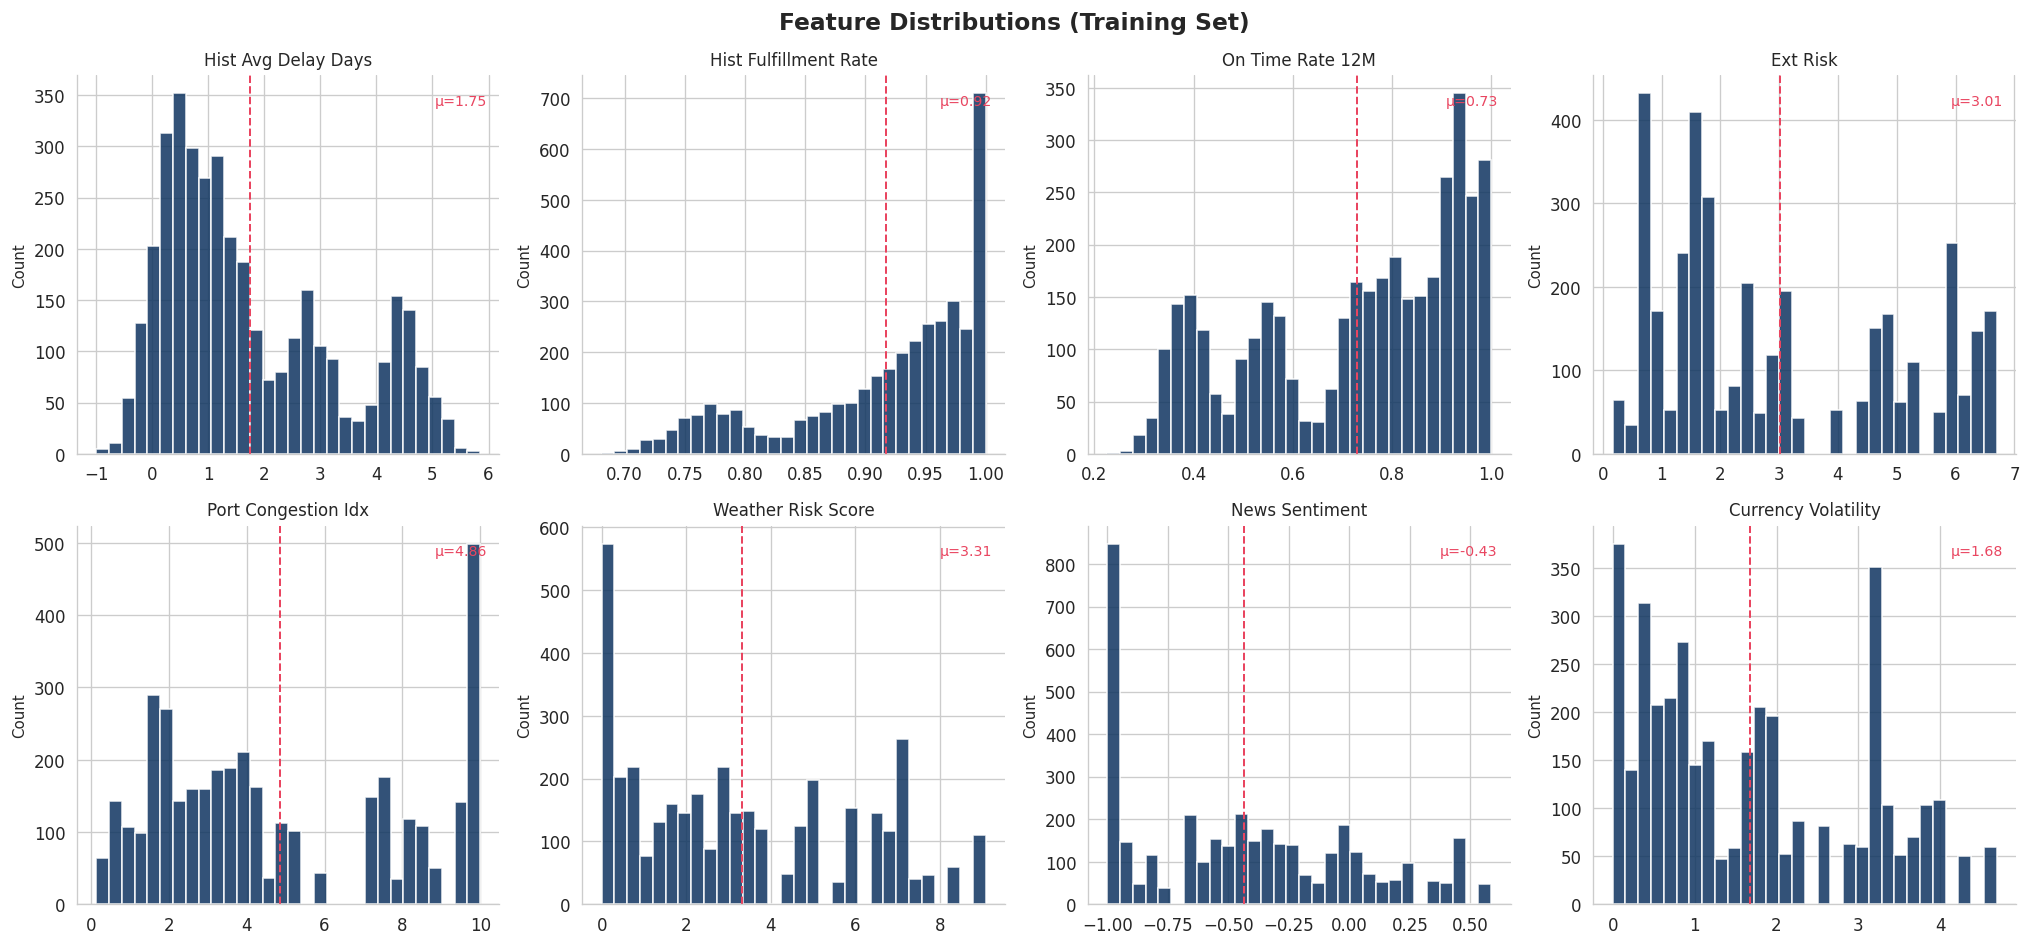

In [36]:
# ── Feature distribution overview ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle("Feature Distributions (Training Set)", fontsize=14, fontweight="bold")
axes = axes.flatten()

show_feats = ["hist_avg_delay_days","hist_fulfillment_rate","on_time_rate_12m",
              "ext_risk","port_congestion_idx","weather_risk_score",
              "news_sentiment","currency_volatility"]

for ax, feat in zip(axes, show_feats):
    ax.hist(X_train[feat], bins=30, color="#0f3460", edgecolor="white", alpha=0.85)
    ax.set_title(feat.replace("_"," ").title(), fontsize=10)
    ax.set_ylabel("Count", fontsize=9)
    mu = X_train[feat].mean()
    ax.axvline(mu, color="#e94560", linestyle="--", linewidth=1.2)
    ax.text(0.97, 0.95, f"μ={mu:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8.5, color="#e94560")

plt.tight_layout()
plt.show()


---
## 5 · Model Training

Three specialised models are trained — one per prediction task:

| Model | Algorithm | Target | Business Purpose |
|-------|-----------|--------|-----------------|
| **Delay Regressor** | Random Forest | `delay_days` | Predict how many days late a vendor will be |
| **Fulfillment Regressor** | Gradient Boosting | `fulfillment_ratio` | Predict what fraction of the order will be delivered |
| **Risk Classifier** | Random Forest | `high_risk` | Flag vendor-orders that exceed the risk threshold |


In [53]:
# ── Model 1 — Delay Regressor (Random Forest) ────────────────────────────────
rf_delay = RandomForestRegressor(
    n_estimators  = 300,
    max_depth     = 6,
    min_samples_leaf = 8,
    n_jobs        = -1,
    random_state  = RANDOM_STATE,
)
rf_delay.fit(X_train, yd_train)
print("  ✔  Delay Regressor (Random Forest) — trained")

# ── Model 2 — Fulfillment Regressor (Gradient Boosting) ──────────────────────
gb_fulfill = GradientBoostingRegressor(
    n_estimators  = 300,
    learning_rate = 0.04,
    max_depth     = 3,
    random_state  = RANDOM_STATE,
)
gb_fulfill.fit(X_train, yf_train)
print("  ✔  Fulfillment Regressor (Gradient Boosting) — trained")

# ── Model 3 — Risk Classifier (Random Forest) ────────────────────────────────
rf_risk = RandomForestClassifier(
    n_estimators  = 300,
    max_depth     = 8,
    min_samples_leaf = 5,
    class_weight  = "balanced",
    n_jobs        = -1,
    random_state  = RANDOM_STATE,
)
rf_risk.fit(X_train, yr_train)
print("  ✔  Risk Classifier (Random Forest) — trained")
print()
print("All three models ready for evaluation.")


  ✔  Delay Regressor (Random Forest) — trained
  ✔  Fulfillment Regressor (Gradient Boosting) — trained
  ✔  Risk Classifier (Random Forest) — trained

All three models ready for evaluation.


---
## 6 · Model Evaluation

### 6.1 · Regression Performance — Delay & Fulfillment


In [38]:
pred_delay   = rf_delay.predict(X_test)
pred_fulfill = gb_fulfill.predict(X_test)
pred_risk    = rf_risk.predict(X_test)
pred_prob    = rf_risk.predict_proba(X_test)[:, 1]

# ── Metric table ─────────────────────────────────────────────────────────────
rmse_d  = np.sqrt(mean_squared_error(yd_test, pred_delay))
mae_d   = mean_absolute_error(yd_test, pred_delay)
r2_d    = r2_score(yd_test, pred_delay)

rmse_f  = np.sqrt(mean_squared_error(yf_test, pred_fulfill))
mae_f   = mean_absolute_error(yf_test, pred_fulfill)
r2_f    = r2_score(yf_test, pred_fulfill)

auc     = roc_auc_score(yr_test, pred_prob)
acc     = accuracy_score(yr_test, pred_risk)
f1      = f1_score(yr_test, pred_risk, zero_division=0)

metrics = pd.DataFrame({
    "Model"  : ["Delay Regressor (RF)", "Fulfillment Regressor (GB)", "Risk Classifier (RF)"],
    "RMSE"   : [f"{rmse_d:.3f} days",  f"{rmse_f:.4f}",              "—"],
    "MAE"    : [f"{mae_d:.3f} days",   f"{mae_f:.4f}",               "—"],
    "R²"     : [f"{r2_d:.3f}",         f"{r2_f:.3f}",                "—"],
    "AUC"    : ["—",                   "—",                          f"{auc:.3f}"],
    "Accuracy": ["—",                  "—",                          f"{acc:.3f}"],
    "F1"     : ["—",                   "—",                          f"{f1:.3f}"],
})
display(metrics.set_index("Model"))


,RMSE,MAE,R²,AUC,Accuracy,F1
Model,,,,,,
Delay Regressor (RF),1.922 days,1.396 days,0.347,—,—,—
Fulfillment Regressor (GB),0.0717,0.0572,0.427,—,—,—
Risk Classifier (RF),—,—,—,0.864,0.802,0.731


### 6.2 · Actual vs Predicted Plots

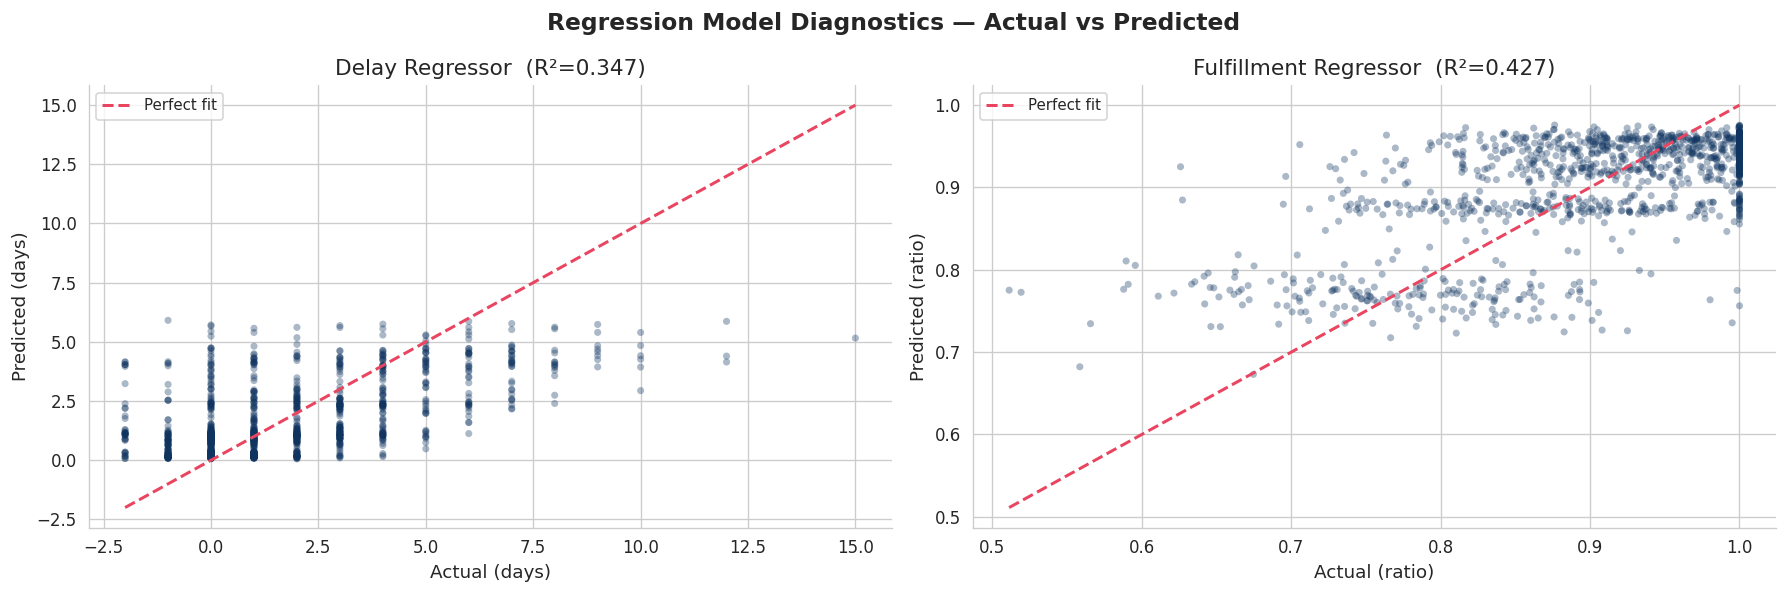

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Regression Model Diagnostics — Actual vs Predicted", 
             fontsize=14, fontweight="bold")

for ax, actual, pred, title, unit in [
    (axes[0], yd_test, pred_delay,   f"Delay Regressor  (R²={r2_d:.3f})", "days"),
    (axes[1], yf_test, pred_fulfill, f"Fulfillment Regressor  (R²={r2_f:.3f})", "ratio"),
]:
    ax.scatter(actual, pred, alpha=0.35, s=18, color="#0f3460", edgecolors="none")
    lo, hi = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], color="#e94560", linewidth=1.8, linestyle="--", label="Perfect fit")
    ax.set_title(title)
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 6.3 · Risk Classifier — Confusion Matrix & Classification Report

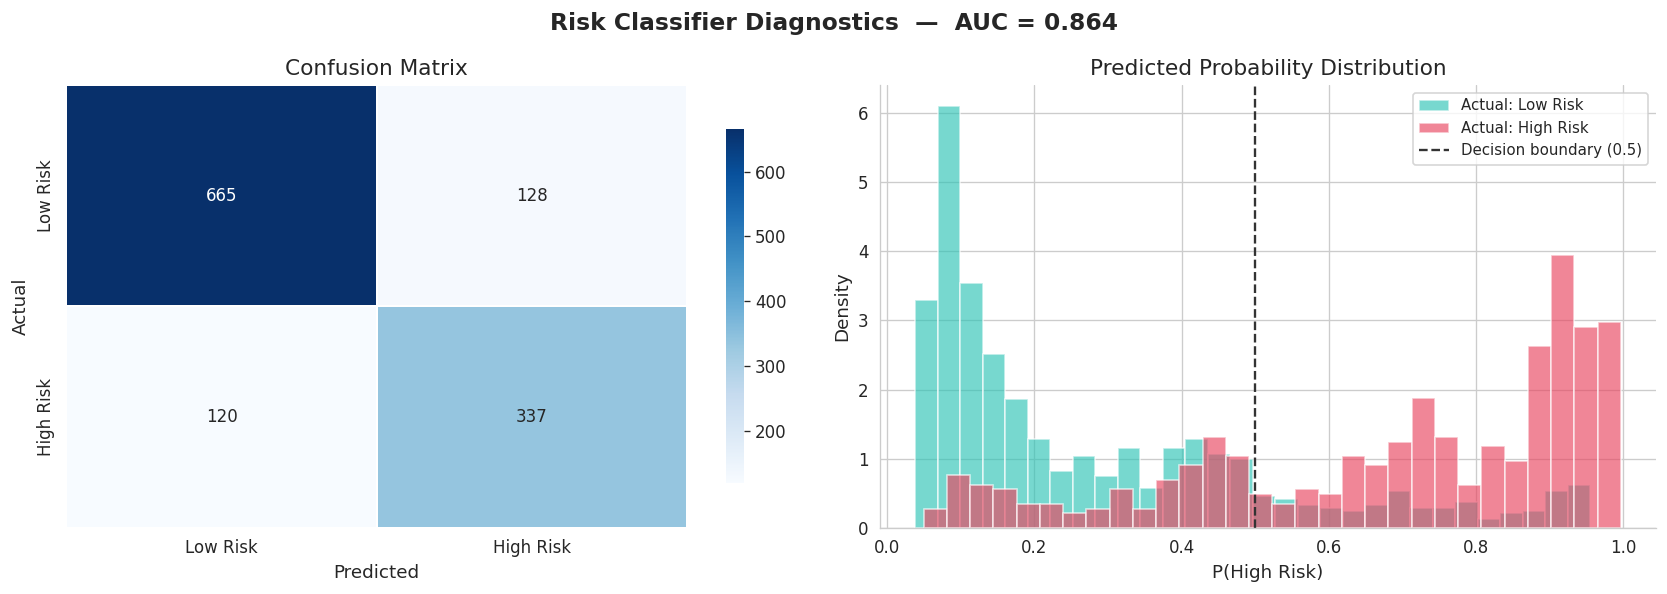


Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.85      0.84      0.84       793
   High Risk       0.72      0.74      0.73       457

    accuracy                           0.80      1250
   macro avg       0.79      0.79      0.79      1250
weighted avg       0.80      0.80      0.80      1250



In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Risk Classifier Diagnostics  —  AUC = {auc:.3f}", 
             fontsize=14, fontweight="bold")

# — Confusion matrix —
cm = confusion_matrix(yr_test, pred_risk)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "High Risk"],
            yticklabels=["Low Risk", "High Risk"],
            linewidths=1, ax=axes[0],
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

# — Prediction probability distribution —
low_probs  = pred_prob[yr_test == 0]
high_probs = pred_prob[yr_test == 1]
axes[1].hist(low_probs,  bins=30, alpha=0.65, color="#2ec4b6", label="Actual: Low Risk",  density=True)
axes[1].hist(high_probs, bins=30, alpha=0.65, color="#e94560", label="Actual: High Risk", density=True)
axes[1].axvline(0.5, color="#333", linestyle="--", linewidth=1.4, label="Decision boundary (0.5)")
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("P(High Risk)"); axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(yr_test, pred_risk, target_names=["Low Risk", "High Risk"]))


### 6.4 · Feature Importance

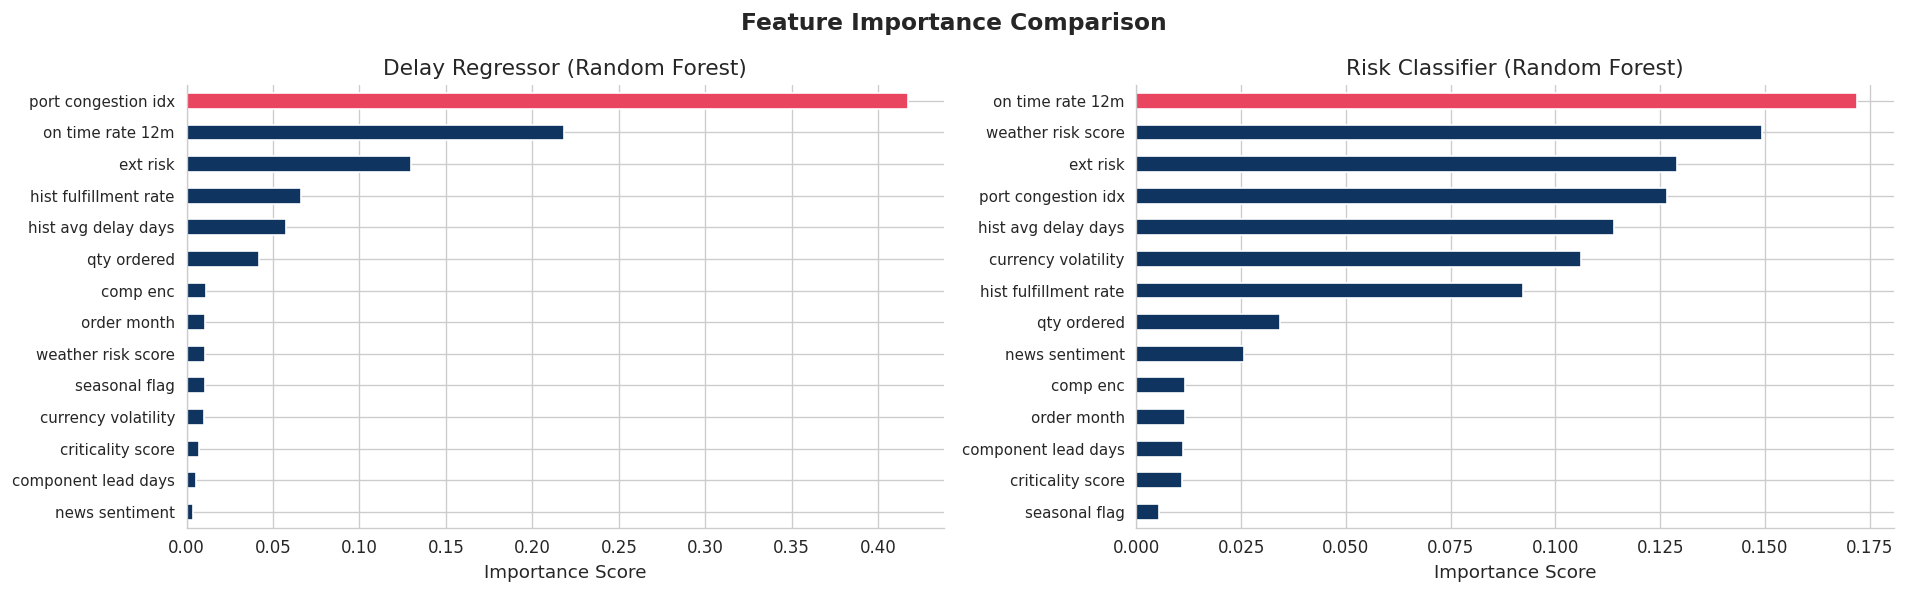

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Feature Importance Comparison", fontsize=14, fontweight="bold")

for ax, model, title in [
    (axes[0], rf_delay,  "Delay Regressor (Random Forest)"),
    (axes[1], rf_risk,   "Risk Classifier (Random Forest)"),
]:
    fi = (pd.Series(model.feature_importances_, index=FEATURES)
          .sort_values(ascending=True))
    colors = ["#e94560" if v == fi.max() else "#0f3460" for v in fi.values]
    fi.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Importance Score")
    ax.set_yticklabels([f.replace("_"," ") for f in fi.index], fontsize=9)

plt.tight_layout()
plt.show()


### 6.5 · Cross-Validation Stability

5-Fold Cross-Validation Results
──────────────────────────────────────────────────────────────────────


,Metric,CV Mean,CV Std,Fold Scores
Model,,,,
Delay Regressor (RF),MAE (days),1.4038,0.0163,1.400 | 1.432 | 1.404 | 1.402 | 1.381
Fulfillment Regressor (GB),MAE (ratio),0.0570,0.0013,0.0575 | 0.0561 | 0.0555 | 0.0567 | 0.0593
Risk Classifier (RF),F1 Score,0.7348,0.0099,0.718 | 0.734 | 0.748 | 0.741 | 0.734


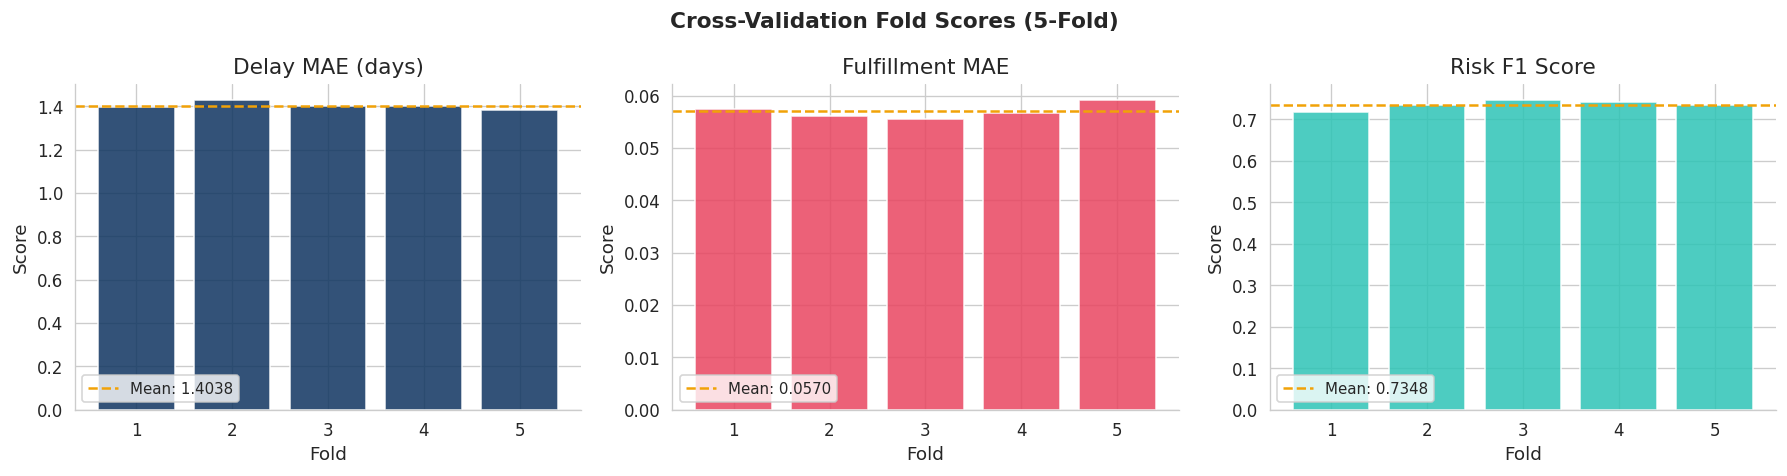

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_delay   = -cross_val_score(rf_delay,   X, y_delay,   cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)
cv_fulfill = -cross_val_score(gb_fulfill, X, y_fulfill, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)
cv_risk    =  cross_val_score(rf_risk,    X, y_risk,    cv=kf, scoring="f1",                      n_jobs=-1)

cv_results = pd.DataFrame({
    "Model"    : ["Delay Regressor (RF)", "Fulfillment Regressor (GB)", "Risk Classifier (RF)"],
    "Metric"   : ["MAE (days)", "MAE (ratio)", "F1 Score"],
    "CV Mean"  : [cv_delay.mean(),   cv_fulfill.mean(),   cv_risk.mean()],
    "CV Std"   : [cv_delay.std(),    cv_fulfill.std(),    cv_risk.std()],
    "Fold Scores": [
        " | ".join([f"{v:.3f}" for v in cv_delay]),
        " | ".join([f"{v:.4f}" for v in cv_fulfill]),
        " | ".join([f"{v:.3f}" for v in cv_risk]),
    ]
})
print("5-Fold Cross-Validation Results")
print("─" * 70)
display(cv_results.set_index("Model").style.format({"CV Mean": "{:.4f}", "CV Std": "{:.4f}"}))

# — Variance plot —
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Cross-Validation Fold Scores (5-Fold)", fontsize=13, fontweight="bold")

for ax, scores, label, color in [
    (axes[0], cv_delay,   "Delay MAE (days)",   "#0f3460"),
    (axes[1], cv_fulfill, "Fulfillment MAE",     "#e94560"),
    (axes[2], cv_risk,    "Risk F1 Score",       "#2ec4b6"),
]:
    folds = range(1, len(scores)+1)
    ax.bar(folds, scores, color=color, edgecolor="white", alpha=0.85)
    ax.axhline(scores.mean(), color="#f1a208", linestyle="--", linewidth=1.5,
               label=f"Mean: {scores.mean():.4f}")
    ax.set_title(label); ax.set_xlabel("Fold"); ax.set_ylabel("Score")
    ax.set_xticks(list(folds))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 7 · Procurement Orchestration Engine

Using the trained models to generate **risk-adjusted purchase orders** with split-sourcing recommendations.

The orchestration logic follows the formula defined in the StockSense specification:

$$\text{Order\_Qty} = \frac{\text{Required\_Qty}}{\text{Predicted\_Fulfillment\_Rate}} \times (1 + \text{Risk\_Buffer})$$

Where `Risk_Buffer` = 5% base + up to 30% additional for high-risk vendors.

### 7.1 · Vendor Risk Profile


In [46]:
# ── Build full vendor × component risk profile ───────────────────────────────
agg = vendor_df.groupby(["vendor_id","component_id"]).agg(
    avg_delay        = ("delay_days",        "mean"),
    volatility       = ("delay_days",        "std"),
    fulfillment_rate = ("fulfillment_ratio",  "mean"),
    order_count      = ("qty_ordered",        "count"),
).reset_index().fillna(0)

agg["comp_enc"]  = le_comp.transform(agg["component_id"])
agg["order_month"] = 6   # mid-year baseline
agg["seasonal_flag"] = 0

ext_agg = ext_df.groupby("vendor_id").agg(
    on_time_rate_12m     = ("weather_risk_score", lambda x: 1 - x.mean()/10),
    hist_avg_delay_days  = ("port_congestion_idx", lambda x: x.mean()/3),
    hist_fulfillment_rate= ("currency_volatility",  lambda x: 1 - x.mean()/10),
    ext_risk             = ("port_congestion_idx", lambda x: (
        0.35*x.mean() + 0.25*2 + 0.20*0.5 + 0.20*1)),
    port_congestion_idx  = ("port_congestion_idx", "mean"),
    weather_risk_score   = ("weather_risk_score",  "mean"),
    news_sentiment       = ("news_sentiment",       "mean"),
    currency_volatility  = ("currency_volatility",  "mean"),
).reset_index()

risk_df = agg.merge(ext_agg, on="vendor_id", how="left")

# Ensure all FEATURES columns are present
for col in ["criticality_score","qty_ordered","component_lead_days"]:
    if col not in risk_df.columns:
        if col == "criticality_score":
            crit_map = dict(zip(bom_df["component_id"], bom_df["criticality_score"]))
            risk_df["criticality_score"] = risk_df["component_id"].map(crit_map).fillna(0.5)
        elif col == "component_lead_days":
            lead_map = dict(zip(bom_df["component_id"], bom_df["standard_lead_days"]))
            risk_df["component_lead_days"] = risk_df["component_id"].map(lead_map).fillna(10)
        else:
            risk_df["qty_ordered"] = 1000

X_risk = risk_df[FEATURES].fillna(0)
risk_df["pred_delay"]   = rf_delay.predict(X_risk)
risk_df["pred_fulfill"] = gb_fulfill.predict(X_risk)
risk_df["risk_prob"]    = rf_risk.predict_proba(X_risk)[:, 1]
risk_df["risk_label"]   = risk_df["risk_prob"].apply(
    lambda p: "🔴 HIGH" if p > 0.6 else ("🟡 MEDIUM" if p > 0.35 else "🟢 LOW"))

display_cols = ["vendor_id","component_id","avg_delay","volatility",
                "fulfillment_rate","pred_delay","pred_fulfill","risk_prob","risk_label"]
print("Vendor × Component Risk Profile (sorted by risk probability):")
display(risk_df[display_cols].sort_values("risk_prob", ascending=False)
        .reset_index(drop=True).round(4))


Vendor × Component Risk Profile (sorted by risk probability):


,vendor_id,component_id,avg_delay,volatility,fulfillment_rate,pred_delay,pred_fulfill,risk_prob,risk_label
0,VND_DELTA,BEARING_01,4.4175,3.4881,0.7668,3.9096,0.7084,0.7563,🔴 HIGH
1,VND_DELTA,BLADE_X,4.5222,3.1381,0.7680,3.9543,0.7032,0.7495,🔴 HIGH
2,VND_DELTA,CABLE_R,4.0244,3.3693,0.7741,3.8704,0.7089,0.7460,🔴 HIGH
3,VND_DELTA,CASING_B,4.3000,2.9879,0.7755,3.9740,0.7157,0.7459,🔴 HIGH
4,VND_DELTA,MOTOR_X,4.0460,3.3022,0.7667,3.7627,0.7007,0.7448,🔴 HIGH
5,VND_DELTA,SWITCH_S,4.4071,3.3076,0.7586,3.9398,0.7051,0.7420,🔴 HIGH
6,VND_DELTA,SCREW_M4,4.5700,3.2357,0.7855,4.0181,0.7166,0.7399,🔴 HIGH
7,VND_DELTA,BATTERY_A,4.6729,3.7005,0.7643,3.8944,0.7241,0.7253,🔴 HIGH
8,VND_BETA,MOTOR_X,2.6723,2.3868,0.8634,3.4284,0.7946,0.6318,🔴 HIGH
9,VND_BETA,CABLE_R,2.5054,2.1449,0.8868,3.5341,0.8003,0.6205,🔴 HIGH


### 7.2 · Risk Probability Heatmap

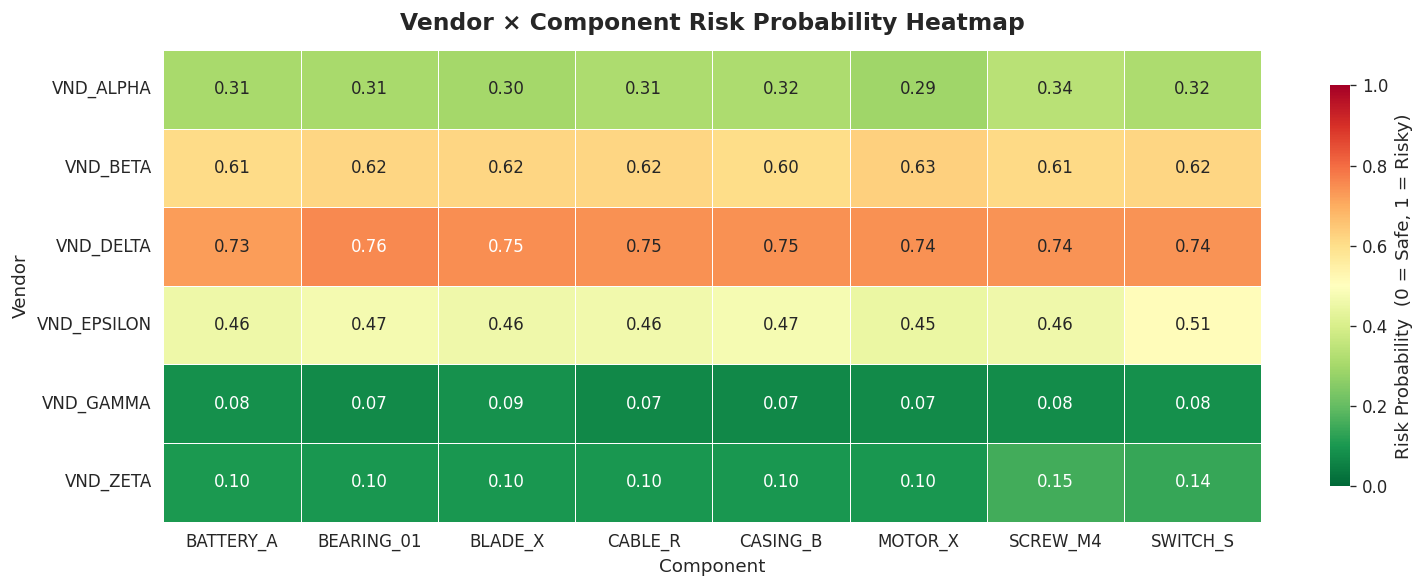

In [47]:
pivot_risk = risk_df.pivot_table(index="vendor_id", columns="component_id",
                                  values="risk_prob", aggfunc="mean")

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_risk, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=0, vmax=1, linewidths=0.6, ax=ax,
            cbar_kws={"label": "Risk Probability  (0 = Safe, 1 = Risky)", "shrink": 0.85})
ax.set_title("Vendor × Component Risk Probability Heatmap", 
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Component"); ax.set_ylabel("Vendor")
plt.tight_layout()
plt.show()


### 7.3 · BOM Explosion — Production Schedule

In [48]:
# ── Production schedule to fulfil ────────────────────────────────────────────
PRODUCTION_SCHEDULE = {
    "DRILL_01"   : 10_000,
    "GRINDER_01" :  5_000,
}

def bom_explode(product_id: str, units: int) -> pd.DataFrame:
    rows = bom_df[bom_df["product_id"] == product_id].copy()
    rows["required_qty"] = rows["qty_per_unit"] * units
    return rows[["component_id","required_qty","standard_lead_days","criticality_score"]]

exploded = []
for prod, qty in PRODUCTION_SCHEDULE.items():
    exp = bom_explode(prod, qty)
    exp["product_id"] = prod
    exploded.append(exp)

req_df = pd.concat(exploded, ignore_index=True)
req_summary = (req_df.groupby("component_id")
               .agg(total_required=("required_qty","sum"),
                    lead_days=("standard_lead_days","first"),
                    criticality=("criticality_score","first"))
               .reset_index()
               .sort_values("total_required", ascending=False))

print("Raw Material Requirements for Production Schedule:")
print(f"  Products: {list(PRODUCTION_SCHEDULE.keys())}")
print(f"  Units:    {list(PRODUCTION_SCHEDULE.values())}")
print()
display(req_summary.reset_index(drop=True))


Raw Material Requirements for Production Schedule:
  Products: ['DRILL_01', 'GRINDER_01']
  Units:    [10000, 5000]



,component_id,total_required,lead_days,criticality
0,CASING_B,205000,7,0.60
1,CABLE_R,100000,8,0.70
2,MOTOR_X,50000,14,0.95
3,BLADE_X,40000,12,0.85
4,SWITCH_S,20000,6,0.65
5,BEARING_01,10000,11,0.80
6,BATTERY_A,10000,10,0.90
7,SCREW_M4,5000,5,0.40


### 7.4 · Risk-Adjusted Purchase Order Generation

In [49]:
RISK_THRESHOLD = 0.50   # risk_prob above this triggers split-sourcing

def compute_order_qty(required: int, pred_fulfill: float, risk_prob: float) -> int:
    """
    Order_Qty = (Demand / Predicted_Fulfillment_Rate) × (1 + Risk_Buffer)
    Risk_Buffer: 5% base + up to 30% additional scaled by risk probability.
    """
    risk_buffer = 0.05 + 0.30 * risk_prob
    return round((required / max(pred_fulfill, 0.5)) * (1 + risk_buffer))

orders = []
for _, row in req_summary.iterrows():
    comp = row["component_id"]
    need = int(row["total_required"])
    crit = row["criticality"]

    cands = risk_df[risk_df["component_id"] == comp].sort_values("risk_prob")
    if cands.empty:
        continue

    primary = cands.iloc[0]
    p_qty   = compute_order_qty(need, primary["pred_fulfill"], primary["risk_prob"])
    split   = bool(primary["risk_prob"] > RISK_THRESHOLD)

    entry = {
        "component_id"        : comp,
        "required_qty"        : need,
        "criticality"         : round(crit, 2),
        "primary_vendor"      : primary["vendor_id"],
        "primary_risk_prob"   : round(primary["risk_prob"], 3),
        "primary_order_qty"   : p_qty,
        "split_sourcing"      : split,
    }

    if split and len(cands) > 1:
        backup = cands.iloc[1]
        b_qty  = compute_order_qty(int(need * 0.35), backup["pred_fulfill"], backup["risk_prob"])
        p_surv = primary["pred_fulfill"]
        b_surv = backup["pred_fulfill"]
        entry.update({
            "backup_vendor"      : backup["vendor_id"],
            "backup_risk_prob"   : round(backup["risk_prob"], 3),
            "backup_order_qty"   : b_qty,
            "combined_coverage"  : round(1 - (1-p_surv)*(1-b_surv), 4),
        })
    else:
        entry.update({
            "backup_vendor"      : "—",
            "backup_risk_prob"   : None,
            "backup_order_qty"   : 0,
            "combined_coverage"  : round(float(primary["pred_fulfill"]), 4),
        })

    orders.append(entry)

orders_df = pd.DataFrame(orders)
orders_df.to_csv(f"{DATA_DIR}/recommended_purchase_orders.csv", index=False)

print("📋  Risk-Adjusted Purchase Order Recommendations")
print(f"    {orders_df['split_sourcing'].sum()} of {len(orders_df)} components flagged for split-sourcing\n")
display(orders_df)


📋  Risk-Adjusted Purchase Order Recommendations
    0 of 8 components flagged for split-sourcing



,component_id,required_qty,criticality,primary_vendor,primary_risk_prob,primary_order_qty,split_sourcing,backup_vendor,backup_risk_prob,backup_order_qty,combined_coverage
0,CASING_B,205000,0.60,VND_GAMMA,0.067,230003,False,—,None,0,0.9538
1,CABLE_R,100000,0.70,VND_GAMMA,0.070,112296,False,—,None,0,0.9538
2,MOTOR_X,50000,0.95,VND_GAMMA,0.073,56324,False,—,None,0,0.9516
3,BLADE_X,40000,0.85,VND_GAMMA,0.087,45142,False,—,None,0,0.9536
4,SWITCH_S,20000,0.65,VND_GAMMA,0.083,22553,False,—,None,0,0.9533
5,BEARING_01,10000,0.80,VND_GAMMA,0.072,11239,False,—,None,0,0.9536
6,BATTERY_A,10000,0.90,VND_GAMMA,0.083,11271,False,—,None,0,0.9538
7,SCREW_M4,5000,0.40,VND_GAMMA,0.077,5629,False,—,None,0,0.9533


### 7.5 · Split-Sourcing Visualisation

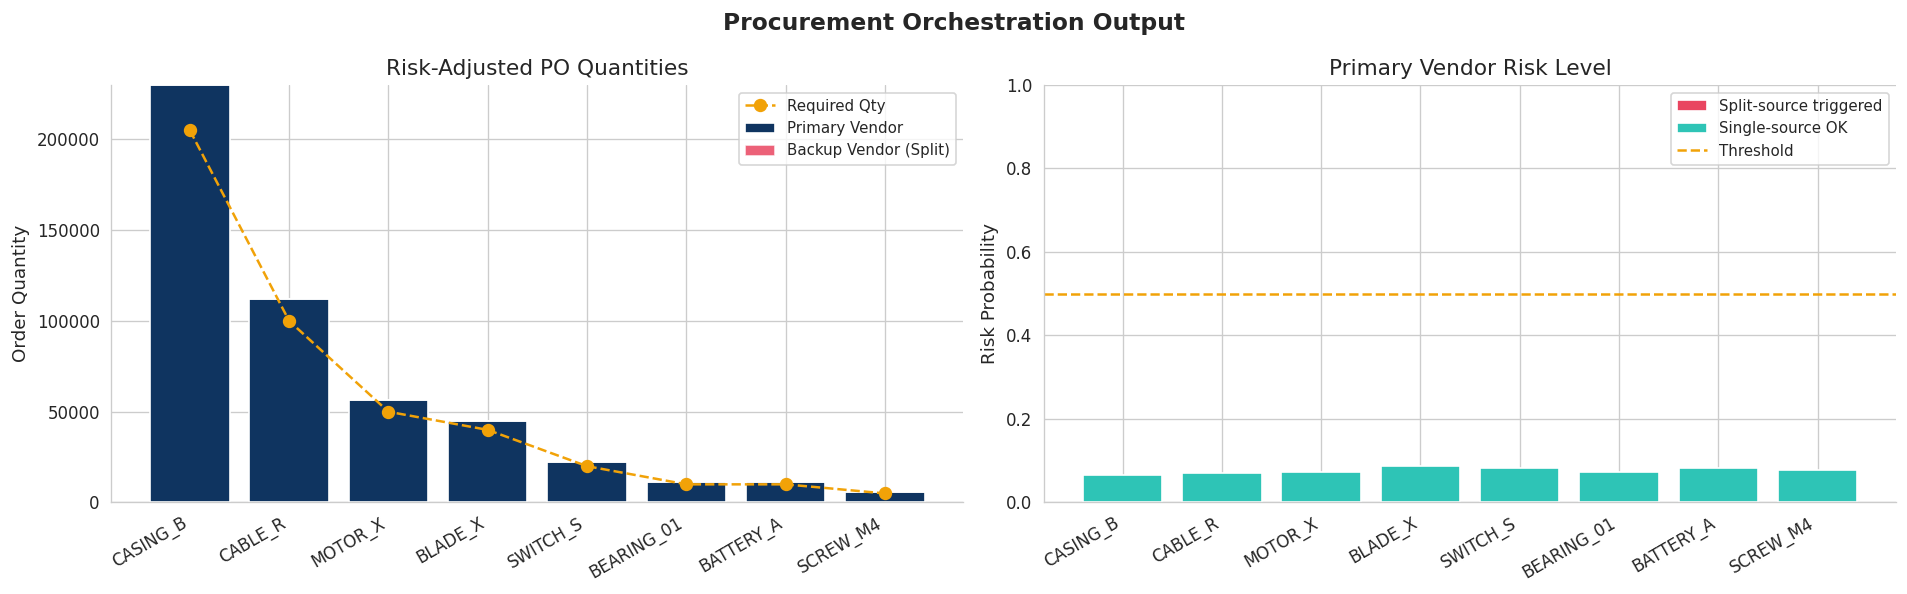

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Procurement Orchestration Output", fontsize=14, fontweight="bold")

# — Stacked order quantities —
x = np.arange(len(orders_df))
p_bars = axes[0].bar(x, orders_df["primary_order_qty"],
                     label="Primary Vendor", color="#0f3460", edgecolor="white")
if "backup_order_qty" in orders_df.columns:
    axes[0].bar(x, orders_df["backup_order_qty"].fillna(0),
                bottom=orders_df["primary_order_qty"],
                label="Backup Vendor (Split)", color="#e94560", alpha=0.85, edgecolor="white")
axes[0].plot(x, orders_df["required_qty"], "o--", color="#f1a208",
             linewidth=1.5, markersize=7, label="Required Qty", zorder=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(orders_df["component_id"], rotation=30, ha="right")
axes[0].set_ylabel("Order Quantity"); axes[0].set_title("Risk-Adjusted PO Quantities")
axes[0].legend(fontsize=9)

# — Risk probability with split-source threshold —
colors = ["#e94560" if s else "#2ec4b6" for s in orders_df["split_sourcing"]]
axes[1].bar(x, orders_df["primary_risk_prob"], color=colors, edgecolor="white")
axes[1].axhline(RISK_THRESHOLD, color="#f1a208", linestyle="--",
                linewidth=1.5, label=f"Split-source threshold ({RISK_THRESHOLD})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(orders_df["component_id"], rotation=30, ha="right")
axes[1].set_ylabel("Risk Probability"); axes[1].set_title("Primary Vendor Risk Level")
axes[1].set_ylim(0, 1)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#e94560", label="Split-source triggered"),
              Patch(facecolor="#2ec4b6", label="Single-source OK"),
              plt.Line2D([0],[0], color="#f1a208", linestyle="--", label="Threshold")]
axes[1].legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.show()


---
## 8 · Results Summary & Business Impact


In [51]:
# ── Performance dashboard ────────────────────────────────────────────────────
BORDER  = "═" * 62
DIVIDER = "─" * 62

print(BORDER)
print("         S T O C K S E N S E   —   Results Dashboard")
print(BORDER)
print()
print("  MODEL PERFORMANCE")
print(DIVIDER)
print(f"  {'Delay Regressor (Random Forest)':<36} RMSE = {rmse_d:.3f} days")
print(f"  {'':36} MAE  = {mae_d:.3f} days  |  R² = {r2_d:.3f}")
print()
print(f"  {'Fulfillment Regressor (Gradient Boosting)':<36} MAE  = {mae_f:.4f}")
print(f"  {'':36} RMSE = {rmse_f:.4f}  |  R² = {r2_f:.3f}")
print()
print(f"  {'Risk Classifier (Random Forest)':<36} AUC  = {auc:.3f}")
print(f"  {'':36} Acc  = {acc:.3f}   |  F1 = {f1:.3f}")
print()
print(DIVIDER)
print("  PROCUREMENT ORCHESTRATION")
print(DIVIDER)
print(f"  Components processed         :  {len(orders_df)}")
print(f"  Split-sourcing recommended   :  {orders_df['split_sourcing'].sum()}")
print(f"  Single-source (trusted)      :  {(~orders_df['split_sourcing']).sum()}")
print()
print(DIVIDER)
print("  OUTPUTS SAVED")
print(DIVIDER)
print(f"  data/recommended_purchase_orders.csv")
print()
print(BORDER)


══════════════════════════════════════════════════════════════
         S T O C K S E N S E   —   Results Dashboard
══════════════════════════════════════════════════════════════

  MODEL PERFORMANCE
──────────────────────────────────────────────────────────────
  Delay Regressor (Random Forest)      RMSE = 1.922 days
                                       MAE  = 1.396 days  |  R² = 0.347

  Fulfillment Regressor (Gradient Boosting) MAE  = 0.0572
                                       RMSE = 0.0717  |  R² = 0.427

  Risk Classifier (Random Forest)      AUC  = 0.864
                                       Acc  = 0.802   |  F1 = 0.731

──────────────────────────────────────────────────────────────
  PROCUREMENT ORCHESTRATION
──────────────────────────────────────────────────────────────
  Components processed         :  8
  Split-sourcing recommended   :  0
  Single-source (trusted)      :  8

──────────────────────────────────────────────────────────────
  OUTPUTS SAVED
─────────────────

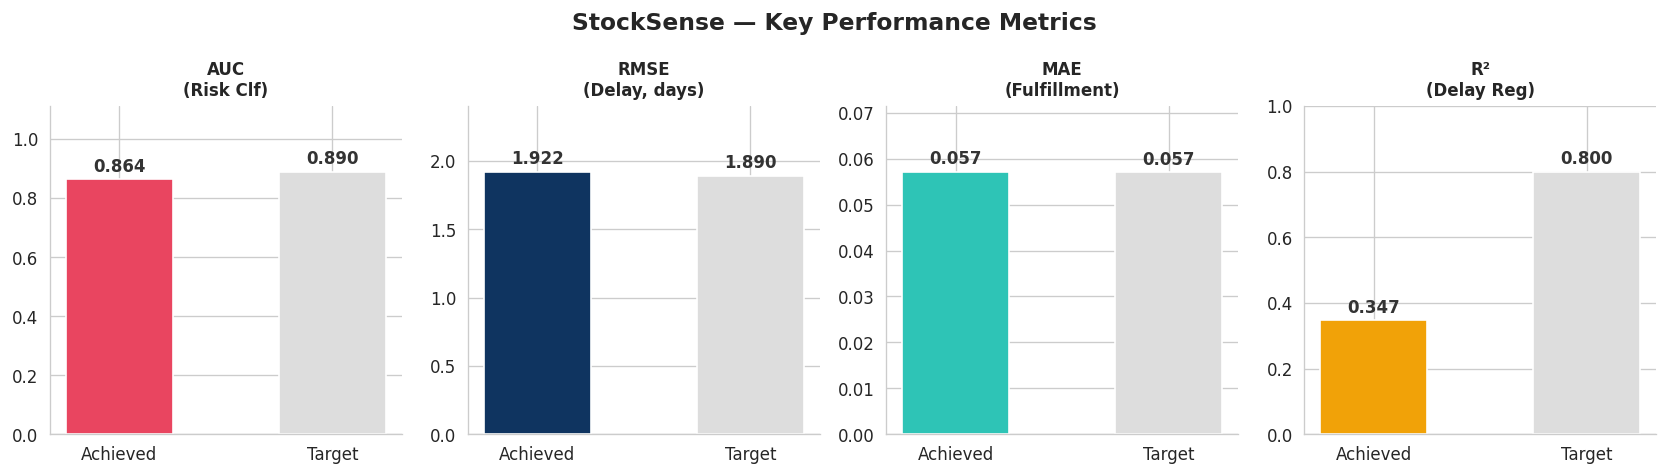


✅  Notebook complete. All outputs saved to data/


In [52]:
# ── Final summary chart ──────────────────────────────────────────────────────
metrics_vals = {
    "AUC\n(Risk Clf)"          : (auc,    0.89, "#e94560"),
    "RMSE\n(Delay, days)"      : (rmse_d, 1.89, "#0f3460"),
    "MAE\n(Fulfillment)"       : (mae_f,  0.057,"#2ec4b6"),
    "R²\n(Delay Reg)"          : (r2_d,   0.80, "#f1a208"),
}

fig, axes = plt.subplots(1, len(metrics_vals), figsize=(14, 4))
fig.suptitle("StockSense — Key Performance Metrics", fontsize=14, fontweight="bold")

for ax, (label, (achieved, target, color)) in zip(axes, metrics_vals.items()):
    ax.bar(["Achieved", "Target"], [achieved, target],
           color=[color, "#ddd"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(achieved, target) * 1.25)
    for i, v in enumerate([achieved, target]):
        ax.text(i, v + max(achieved, target)*0.03, f"{v:.3f}",
                ha="center", fontsize=10, fontweight="bold", color="#333")

plt.tight_layout()
plt.show()
print()
print('✅  Notebook complete. All outputs saved to data/')
